<a href="https://colab.research.google.com/github/hemanshu02/Gemma4_Experiments/blob/main/Gemma4_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

!pip install -U transformers accelerate sentencepiece qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 16.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [3]:
import torch, time, json, gc, re, os
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import requests
from io import BytesIO
import numpy as np

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.0f} GB")

GPU: Tesla T4
VRAM: 16 GB


In [4]:
ALL_RESULTS = []

def show_images(images, titles=None, figsize=(14, 5)):
    """Display a list of PIL images side by side."""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1: axes = [axes]
    for i, img in enumerate(images):
        axes[i].imshow(img)
        if titles: axes[i].set_title(titles[i], fontsize=10)
        axes[i].axis("off")
    plt.tight_layout(); plt.show()

def load_image(url):
    """Download an image from a URL and return a PIL Image."""
    return Image.open(BytesIO(requests.get(url).content)).convert("RGB")

def draw_bboxes(img, bboxes, coord_size=1000):
    """Draw bounding boxes on an image. Boxes are in [y1, x1, y2, x2] format scaled to coord_size."""
    img = img.copy()
    draw = ImageDraw.Draw(img)
    w, h = img.size
    for item in bboxes:
        box = item.get("box_2d", item.get("bbox", []))
        label = item.get("label", "")
        if len(box) == 4:
            y1, x1, y2, x2 = box
            x1, x2 = x1 * w / coord_size, x2 * w / coord_size
            y1, y2 = y1 * h / coord_size, y2 * h / coord_size
            draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
            draw.text((x1, y1 - 15), label, fill="red")
    return img


In [5]:
# === Multi-image reasoning images ===

# A) Spot the difference: two street views
# We'll use two photos of the same landmark from different angles/times
img_bird = load_image("https://huggingface.co/datasets/merve/vlm_test_images/resolve/main/bird.png")
img_thailand = load_image("https://huggingface.co/datasets/merve/vlm_test_images/resolve/main/thailand.jpg")

# B) Two charts to compare
def make_chart(title, cats, vals, colors, fname):
    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.bar(cats, vals, color=colors)
    ax.set_ylabel("Revenue ($M)"); ax.set_title(title); ax.set_ylim(0, 110)
    for i, v in enumerate(vals): ax.text(i, v + 2, str(v), ha="center", fontsize=9)
    plt.tight_layout()
    fig.savefig(fname, dpi=100, bbox_inches="tight"); plt.close()
    return Image.open(fname)

chart_h1 = make_chart("H1 2025 Revenue", ["Jan","Feb","Mar","Apr","May","Jun"],
    [42, 38, 55, 49, 61, 58], ["#4285f4"]*6, "/tmp/chart_h1.png")
chart_h2 = make_chart("H2 2025 Revenue", ["Jul","Aug","Sep","Oct","Nov","Dec"],
    [52, 47, 68, 75, 89, 102], ["#34a853"]*6, "/tmp/chart_h2.png")

# C) Two product screenshots (we create synthetic ones)
def make_product_card(name, price, specs, fname):
    img = Image.new("RGB", (400, 300), "white")
    d = ImageDraw.Draw(img)
    try: font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 20)
    except: font = ImageFont.load_default()
    try: font_sm = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 14)
    except: font_sm = font
    d.text((20, 20), name, fill="black", font=font)
    d.text((20, 55), price, fill="#ea4335", font=font)
    for i, spec in enumerate(specs):
        d.text((20, 95 + i * 25), f"• {spec}", fill="#333", font=font_sm)
    img.save(fname)
    return Image.open(fname)

product_a = make_product_card("UltraBook Pro X1", "$1,299",
    ["CPU: M4 Pro 12-core", "RAM: 24 GB unified", "SSD: 512 GB",
     "Display: 14.2\" Retina", "Battery: 18 hours", "Weight: 1.55 kg"],
    "/tmp/product_a.png")
product_b = make_product_card("ThinkPad Z16 Gen 3", "$1,449",
    ["CPU: Ryzen 9 8945HS", "RAM: 32 GB DDR5", "SSD: 1 TB",
     "Display: 16\" OLED 2.8K", "Battery: 12 hours", "Weight: 1.95 kg"],
    "/tmp/product_b.png")

print("✓ Multi-image test images ready")

✓ Multi-image test images ready


In [6]:
# === Adversarial vision images ===

# A) Rotated text — take a receipt-like image, rotate 180°
receipt = Image.new("RGB", (400, 250), "white")
d = ImageDraw.Draw(receipt)
try: font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf", 15)
except: font = ImageFont.load_default()
for i, line in enumerate(["INVOICE #4821", "Item: Widget Pro  $45.00",
    "Item: Gadget XL   $89.50", "Tax (8%)          $10.76",
    "TOTAL            $145.26"]):
    d.text((20, 20 + i * 35), line, fill="black", font=font)
receipt_rotated = receipt.rotate(180)

# B) Misleading chart — Y-axis starts at 95 instead of 0
fig, ax = plt.subplots(figsize=(5, 3.5))
teams = ["Team A", "Team B", "Team C", "Team D"]
scores = [97, 98, 99, 100]
ax.bar(teams, scores, color=["#4285f4", "#ea4335", "#fbbc04", "#34a853"])
ax.set_ylim(95, 101)  # misleading!
ax.set_ylabel("Performance Score"); ax.set_title("Team Performance Comparison")
for i, v in enumerate(scores): ax.text(i, v + 0.15, str(v), ha="center", fontsize=10)
plt.tight_layout()
fig.savefig("/tmp/misleading_chart.png", dpi=100, bbox_inches="tight"); plt.close()
misleading_chart = Image.open("/tmp/misleading_chart.png")

# C) Tiny low-res image — shrink to 48x48 then upscale
img_bird_tiny = img_bird.resize((48, 48), Image.BILINEAR).resize(img_bird.size, Image.NEAREST)

# D) Contradictory text-on-color — red square with "BLUE" written on it
stroop = Image.new("RGB", (300, 200), "#DD0000")
d = ImageDraw.Draw(stroop)
try: big_font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 60)
except: big_font = ImageFont.load_default()
d.text((65, 60), "BLUE", fill="white", font=big_font)

# E) Non-Latin text image — Japanese text
jp_text = Image.new("RGB", (400, 150), "#FFFFF0")
d = ImageDraw.Draw(jp_text)
try: jp_font = ImageFont.truetype("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc", 28)
except:
    try: jp_font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 22)
    except: jp_font = ImageFont.load_default()
d.text((20, 20), "東京タワーの高さは333mです", fill="black", font=jp_font)
d.text((20, 70), "建設年: 1958年12月23日", fill="#555", font=jp_font)

print("✓ Adversarial test images ready")


✓ Adversarial test images ready


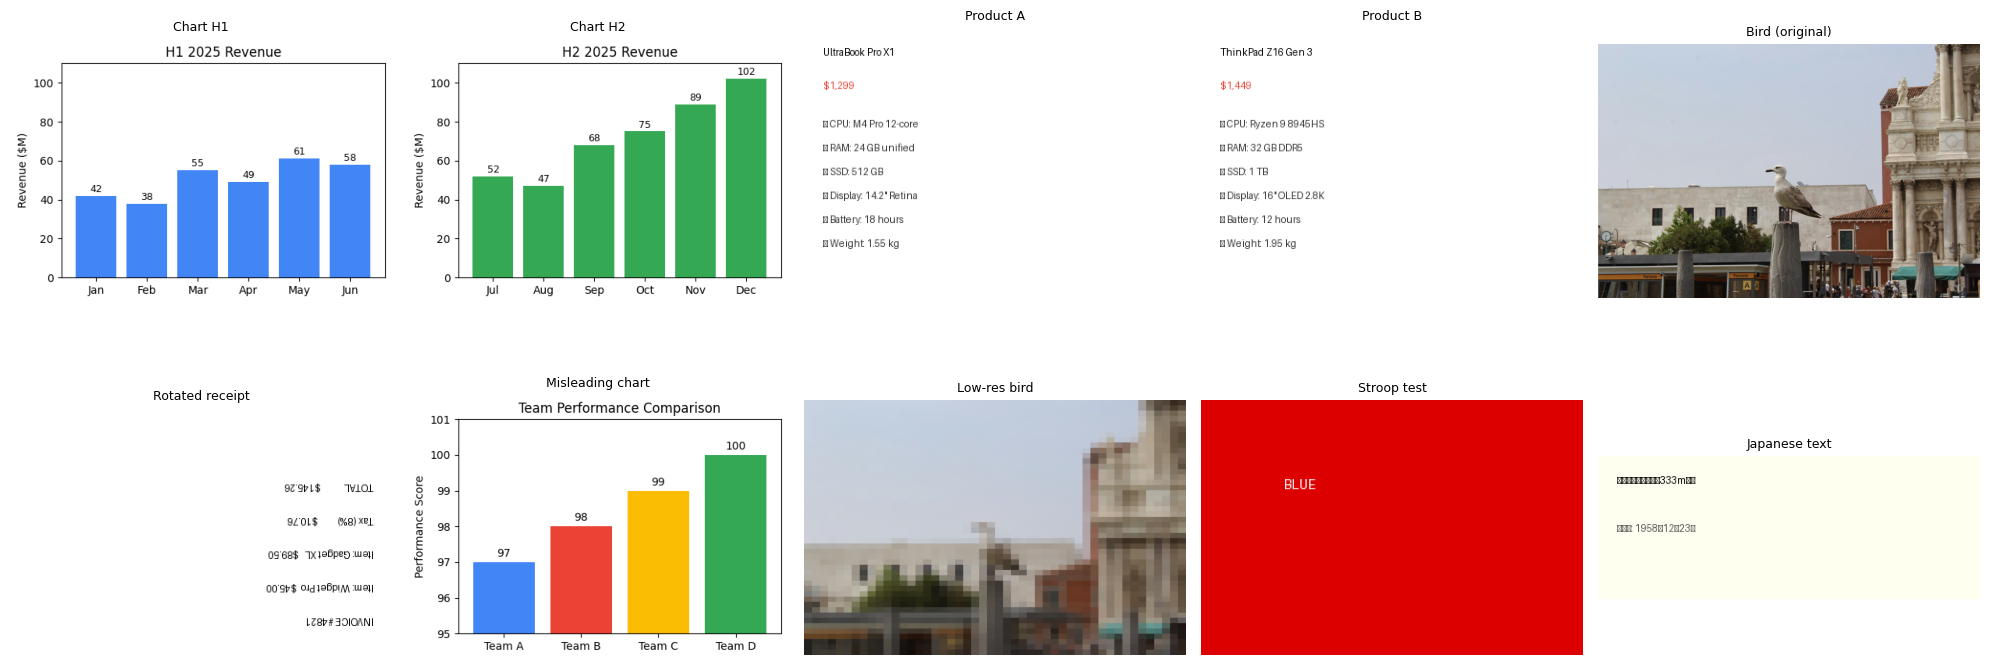

In [7]:
# Preview all test images
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

previews = [
    (chart_h1, "Chart H1"), (chart_h2, "Chart H2"),
    (product_a, "Product A"), (product_b, "Product B"),
    (img_bird, "Bird (original)"),
    (receipt_rotated, "Rotated receipt"), (misleading_chart, "Misleading chart"),
    (img_bird_tiny, "Low-res bird"), (stroop, "Stroop test"),
    (jp_text, "Japanese text"),
]
for ax, (img, title) in zip(axes.flat, previews):
    ax.imshow(img); ax.set_title(title, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:

from transformers import AutoModelForMultimodalLM, AutoProcessor

GEMMA_ID = "google/gemma-4-31B-it"

gemma_processor = AutoProcessor.from_pretrained(GEMMA_ID)
gemma_model = AutoModelForMultimodalLM.from_pretrained(
    GEMMA_ID, torch_dtype=torch.bfloat16, device_map="auto"
)
gemma_model.eval()
print(f"✓ Gemma 4 31B loaded — {torch.cuda.memory_allocated()/1e9:.1f} GB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]